In [2]:
# Patient Analysis Across Departments
import pandas as pd
import numpy as np

# Loading Dataset
df = pd.read_csv('D:\medical_operations_master.csv')
df.head()

,Patient_ID,Age,Gender,Department_Patient,Diagnosis,Severity_Level,Admission_Date,Discharge_Date,Length_of_Stay_Days,Wait_Time_Minutes,...,Hospital_Name,Branch,City,State,Hospital_Type,Total_Beds,Latitude,Longitude,Nurse_ID,Nurse_Name
0,PAT000001,23,Male,Gynecology,Cancer,Low,2026-05-02,2026-05-04,2,79,...,CARE Hospitals,Banjara Hills,Hyderabad,Telangana,Private,435,17.3850,78.4867,N289,Deepak Verma
1,PAT000002,48,Male,Neurology,Kidney Disease,Medium,2026-03-24,2026-03-30,6,167,...,PGIMER,Sector 12,Chandigarh,Chandigarh,Government,1740,30.7333,76.7794,N053,Pooja Singh
2,PAT000003,63,Male,Neurology,Stroke,Low,2025-09-07,2025-09-10,3,281,...,Fortis Hospital,Jaipur,Jaipur,Rajasthan,Private,350,26.9124,75.7873,N051,Priya Kumar
3,PAT000004,85,Male,Emergency,Asthma,Medium,2024-11-19,2024-11-21,2,271,...,KIMS Hospital,Secunderabad,Hyderabad,Telangana,Private,600,17.3850,78.4867,N290,Meera Nair
4,PAT000005,93,Female,Neurology,Pneumonia,Medium,2024-07-20,2024-07-27,7,112,...,Apollo Hospital,Greams Road,Chennai,Tamil Nadu,Private,600,13.0827,80.2707,N112,Rahul Verma


In [3]:
df.shape

(100000, 28)

In [4]:
df.columns


Index(['Patient_ID', 'Age', 'Gender', 'Department_Patient', 'Diagnosis',
       'Severity_Level', 'Admission_Date', 'Discharge_Date',
       'Length_of_Stay_Days', 'Wait_Time_Minutes', 'Doctor_ID',
       'Insurance_Type', 'Treatment_Cost_USD', 'Readmission_Flag', 'Outcome',
       'Doctor_Name', 'Department_Doctor', 'Hospital_ID', 'Hospital_Name',
       'Branch', 'City', 'State', 'Hospital_Type', 'Total_Beds', 'Latitude',
       'Longitude', 'Nurse_ID', 'Nurse_Name'],
      dtype='object')

In [5]:
df.describe()

,Age,Length_of_Stay_Days,Wait_Time_Minutes,Treatment_Cost_USD,Readmission_Flag,Total_Beds,Latitude,Longitude
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,47.426220,5.357330,152.036470,4893.894900,0.074770,1119.641100,21.907142,78.555627
std,27.729468,4.966795,85.560948,7710.109305,0.263021,883.955084,5.861113,3.607463
min,0.000000,1.000000,5.000000,100.000000,0.000000,350.000000,12.916500,72.877700
25%,23.000000,2.000000,78.000000,662.000000,0.000000,550.000000,17.385000,76.717900
50%,47.000000,3.000000,152.000000,2142.000000,0.000000,750.000000,23.344100,77.594600
75%,71.000000,7.000000,226.000000,5002.250000,0.000000,1250.000000,26.912400,80.270700
max,95.000000,30.000000,300.000000,49999.000000,1.000000,4500.000000,30.733300,85.309600


In [6]:
df.isnull().sum()

Patient_ID             0
Age                    0
Gender                 0
Department_Patient     0
Diagnosis              0
Severity_Level         0
Admission_Date         0
Discharge_Date         0
Length_of_Stay_Days    0
Wait_Time_Minutes      0
Doctor_ID              0
Insurance_Type         0
Treatment_Cost_USD     0
Readmission_Flag       0
Outcome                0
Doctor_Name            0
Department_Doctor      0
Hospital_ID            0
Hospital_Name          0
Branch                 0
City                   0
State                  0
Hospital_Type          0
Total_Beds             0
Latitude               0
Longitude              0
Nurse_ID               0
Nurse_Name             0
dtype: int64

In [7]:
df["Department_Patient"].value_counts()

Department_Patient
Dermatology        10205
Oncology           10063
Neurology          10049
Cardiology         10025
Emergency          10002
Gynecology         10001
ICU                 9987
Orthopedics         9939
General Surgery     9889
Pediatrics          9840
Name: count, dtype: int64

In [7]:
pip install plotly

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


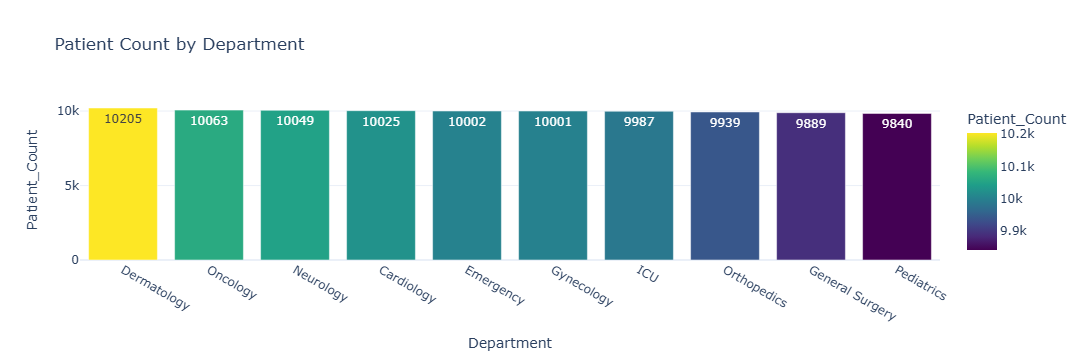

In [24]:
# Patient Count By Department
import plotly.express as px

dept = df["Department_Patient"].value_counts().reset_index()
dept.columns = ["Department", "Patient_Count"]

fig = px.bar(
    dept,
    x="Department",
    y="Patient_Count",
    color="Patient_Count",
    text="Patient_Count",
    color_continuous_scale="Viridis",
    title="Patient Count by Department"
)

fig.update_traces(textposition="inside")
fig.update_layout(template="plotly_white")
fig.show()

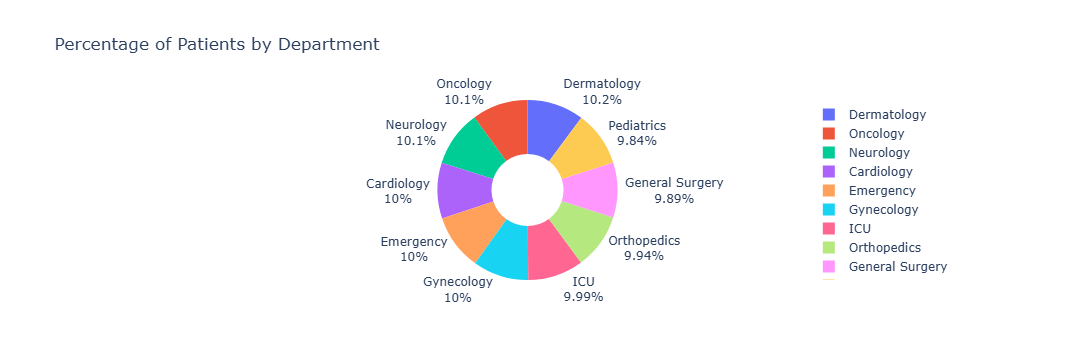

In [13]:
# Percentage of Patients by Department
dept = df["Department_Patient"].value_counts().reset_index()
dept.columns = ["Department", "Patient_Count"]

dept["Percentage"] = (
    dept["Patient_Count"] /
    dept["Patient_Count"].sum() * 100
).round(2)

fig = px.pie(
    dept,
    names="Department",
    values="Percentage",
    hole=0.4,
    title="Percentage of Patients by Department"
)

fig.update_traces(textinfo="percent+label")

fig.show()

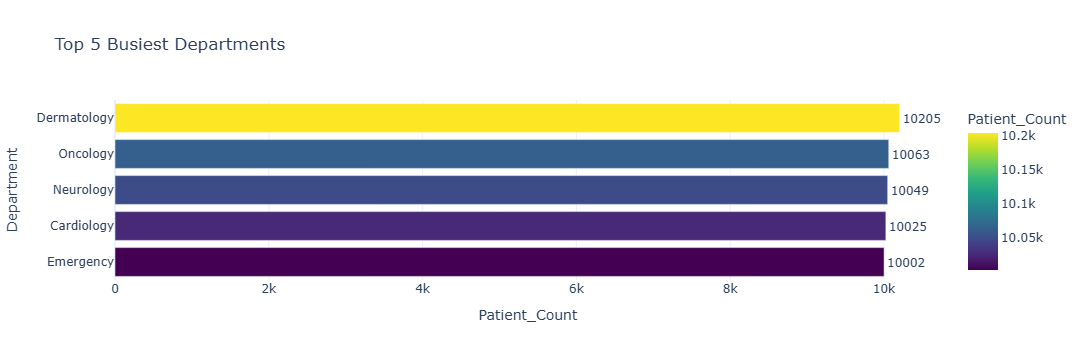

In [27]:
# Top 5 Busiest Departments
import plotly.express as px

top5 = (
    df["Department_Patient"]
    .value_counts()
    .head(5)
    .reset_index()
)

top5.columns = ["Department", "Patient_Count"]

fig = px.bar(
    top5,
    x="Patient_Count",
    y="Department",
    orientation="h",
    color="Patient_Count",
    text="Patient_Count",
    color_continuous_scale="Viridis",
    title="Top 5 Busiest Departments"
)

fig.update_traces(textposition="outside")

fig.update_layout(
    template="plotly_white",
    yaxis=dict(categoryorder="total ascending")
)

fig.show()

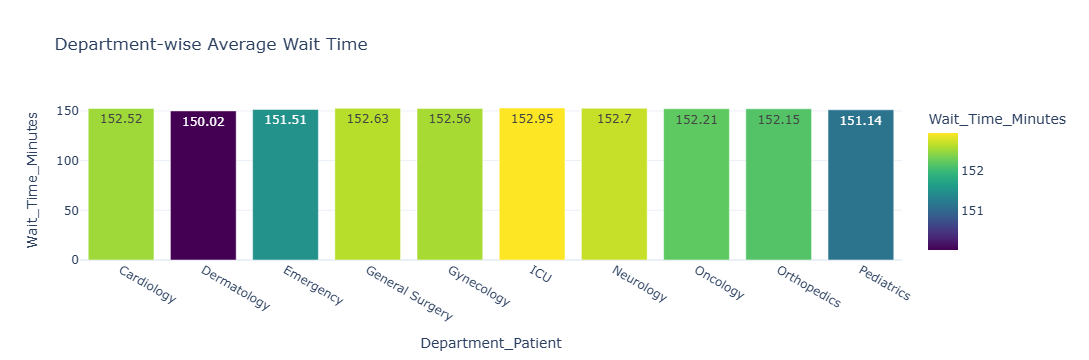

In [16]:
# Department-wise Average Wait Time
dept_wait = (
    df.groupby("Department_Patient")["Wait_Time_Minutes"]
    .mean()
    .reset_index()
)

dept_wait["Wait_Time_Minutes"] = dept_wait["Wait_Time_Minutes"].round(2)

fig = px.bar(
    dept_wait,
    x="Department_Patient",
    y="Wait_Time_Minutes",
    color="Wait_Time_Minutes",
    text="Wait_Time_Minutes",
    color_continuous_scale="Viridis",
    title="Department-wise Average Wait Time"
)

fig.update_traces(textposition="inside")
fig.update_layout(template="plotly_white")

fig.show()

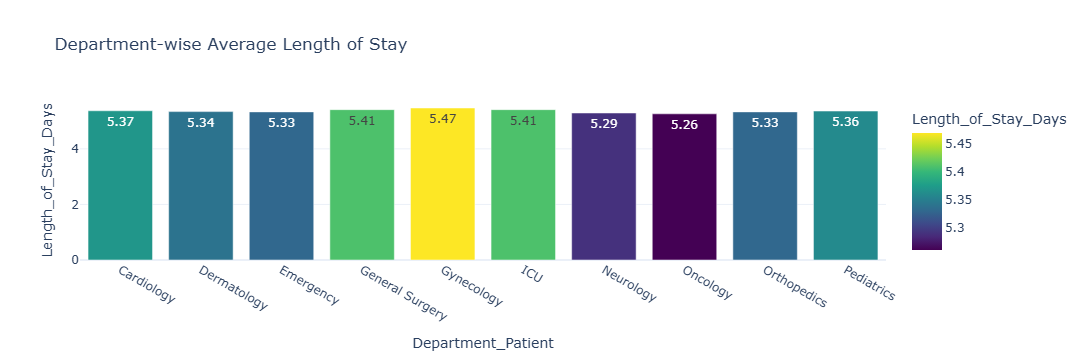

In [18]:
# Department-wise Average Length of Stay
dept_los = (
    df.groupby("Department_Patient")["Length_of_Stay_Days"]
    .mean()
    .reset_index()
)

dept_los["Length_of_Stay_Days"] = dept_los["Length_of_Stay_Days"].round(2)

fig = px.bar(
    dept_los,
    x="Department_Patient",
    y="Length_of_Stay_Days",
    color="Length_of_Stay_Days",
    text="Length_of_Stay_Days",
    color_continuous_scale="Viridis",
    title="Department-wise Average Length of Stay"
)

fig.update_traces(textposition="inside")
fig.update_layout(template="plotly_white")

fig.show()

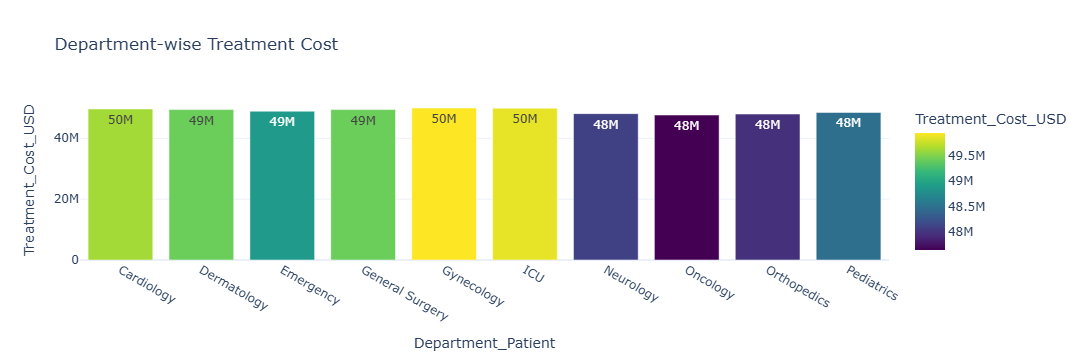

In [20]:
# Department-wise Treatment Cost
dept_cost = (
    df.groupby("Department_Patient")["Treatment_Cost_USD"]
    .sum()
    .reset_index()
)

fig = px.bar(
    dept_cost,
    x="Department_Patient",
    y="Treatment_Cost_USD",
    color="Treatment_Cost_USD",
    text="Treatment_Cost_USD",
    color_continuous_scale="Viridis",
    title="Department-wise Treatment Cost"
)

fig.update_traces(texttemplate='%{text:.2s}', textposition="inside")
fig.update_layout(template="plotly_white")

fig.show()

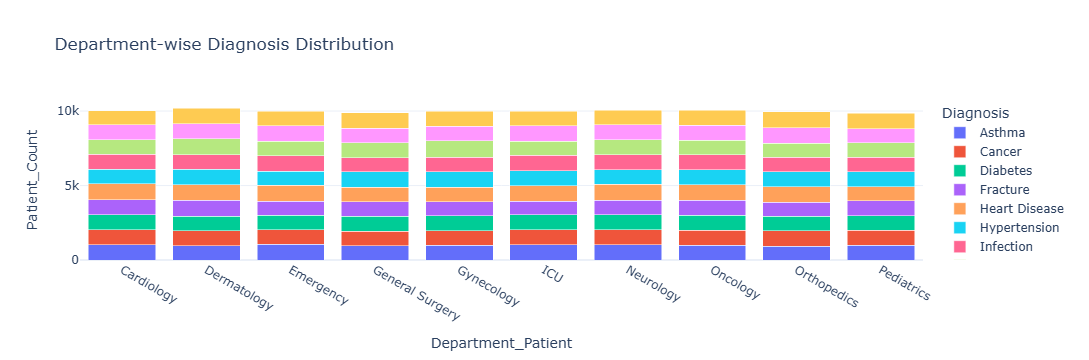

In [21]:
# Department-wise Diagnosis Distribution
diagnosis = (
    df.groupby(["Department_Patient","Diagnosis"])
    .size()
    .reset_index(name="Patient_Count")
)

fig = px.bar(
    diagnosis,
    x="Department_Patient",
    y="Patient_Count",
    color="Diagnosis",
    barmode="stack",
    title="Department-wise Diagnosis Distribution"
)

fig.update_layout(template="plotly_white")

fig.show()

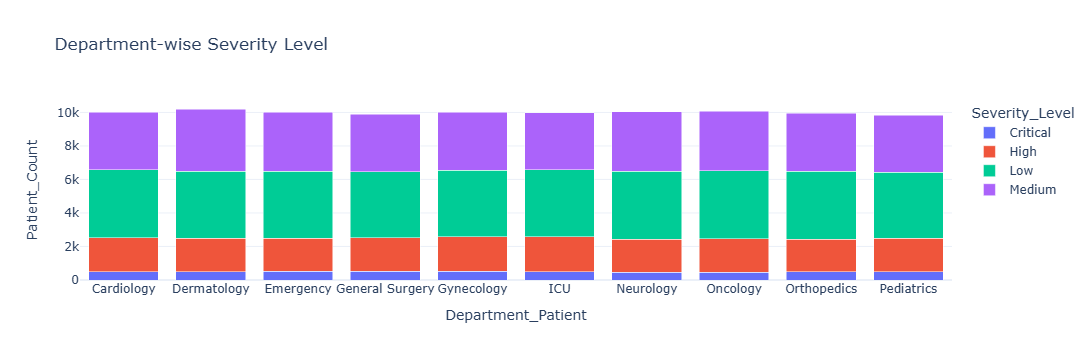

In [22]:
# Department-wise Severity Level
severity = (
    df.groupby(["Department_Patient","Severity_Level"])
    .size()
    .reset_index(name="Patient_Count")
)

fig = px.bar(
    severity,
    x="Department_Patient",
    y="Patient_Count",
    color="Severity_Level",
    barmode="stack",
    title="Department-wise Severity Level"
)

fig.update_layout(template="plotly_white")

fig.show()

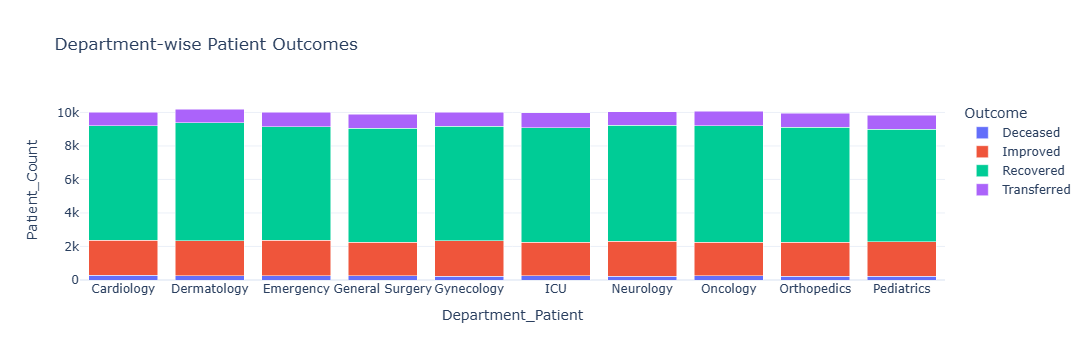

In [23]:
# Department-wise Patient Outcomes
outcome = (
    df.groupby(["Department_Patient","Outcome"])
    .size()
    .reset_index(name="Patient_Count")
)

fig = px.bar(
    outcome,
    x="Department_Patient",
    y="Patient_Count",
    color="Outcome",
    barmode="stack",
    title="Department-wise Patient Outcomes"
)

fig.update_layout(template="plotly_white")

fig.show()